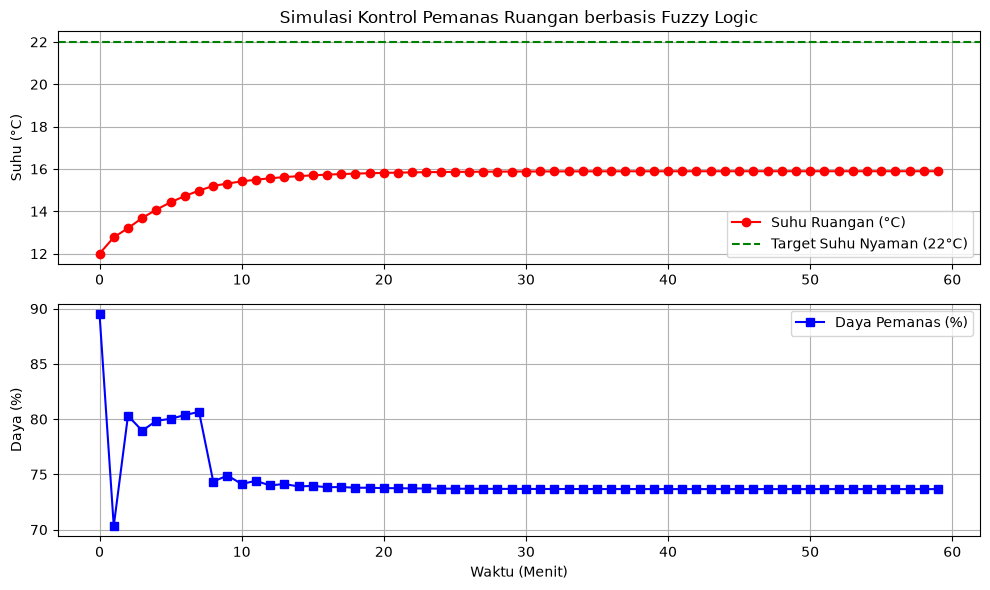

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Definisi Rentang Nilai (Universe of Discourse)
room_temp = ctrl.Antecedent(np.arange(0, 41, 1), 'Room_Temperature')
rate_change = ctrl.Antecedent(np.arange(-5, 6, 1), 'Rate_of_Change')
heater_power = ctrl.Consequent(np.arange(0, 101, 1), 'Heater_Power')

# Kategori Suhu Ruangan (Cold, Cool, Warm, Hot)
room_temp['Cold'] = fuzz.trapmf(room_temp.universe, [0, 0, 10, 18])
room_temp['Cool'] = fuzz.trimf(room_temp.universe, [15, 20, 24])
room_temp['Warm'] = fuzz.trimf(room_temp.universe, [22, 26, 30])
room_temp['Hot']  = fuzz.trapmf(room_temp.universe, [28, 35, 40, 40])

# Kategori Laju Perubahan Suhu (Dropping, Steady, Rising)
rate_change['Dropping'] = fuzz.trapmf(rate_change.universe, [-5, -5, -3, 0])
rate_change['Steady']   = fuzz.trimf(rate_change.universe, [-1, 0, 1])
rate_change['Rising']   = fuzz.trapmf(rate_change.universe, [0, 3, 5, 5])

# Kategori Daya Pemanas (Off, Low, Medium, High)
heater_power['Off']    = fuzz.trimf(heater_power.universe, [0, 0, 10])
heater_power['Low']    = fuzz.trimf(heater_power.universe, [5, 25, 50])
heater_power['Medium'] = fuzz.trimf(heater_power.universe, [40, 60, 80])
heater_power['High']   = fuzz.trimf(heater_power.universe, [70, 100, 100])

rule1 = ctrl.Rule(room_temp['Cold'] & rate_change['Dropping'], heater_power['High'])
rule2 = ctrl.Rule(room_temp['Cold'] & rate_change['Steady'],   heater_power['High'])
rule3 = ctrl.Rule(room_temp['Cold'] & rate_change['Rising'],   heater_power['Medium'])

rule4 = ctrl.Rule(room_temp['Cool'] & rate_change['Dropping'], heater_power['High'])
rule5 = ctrl.Rule(room_temp['Cool'] & rate_change['Steady'],   heater_power['Medium'])
rule6 = ctrl.Rule(room_temp['Cool'] & rate_change['Rising'],   heater_power['Low'])

rule7 = ctrl.Rule(room_temp['Warm'] & rate_change['Dropping'], heater_power['Low'])
rule8 = ctrl.Rule(room_temp['Warm'] & rate_change['Steady'],   heater_power['Off'])
rule9 = ctrl.Rule(room_temp['Warm'] & rate_change['Rising'],   heater_power['Off'])

rule10 = ctrl.Rule(room_temp['Hot'], heater_power['Off'])

# Membangun Sistem Kontrol
heater_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, 
                                  rule6, rule7, rule8, rule9, rule10])
heater_sim = ctrl.ControlSystemSimulation(heater_ctrl)

# Parameter Simulasi Ruangan
waktu_simulasi = 60  # Durasi 60 menit
suhu_luar = 10.0    # Suhu lingkungan luar
suhu_sekarang = 12.0 # Suhu awal ruangan
suhu_sebelumnya = 12.0

data_suhu = []
data_daya = []

for t in range(waktu_simulasi):
    laju_ubah = suhu_sekarang - suhu_sebelumnya
    
    # Input nilai ke sistem Fuzzy
    heater_sim.input['Room_Temperature'] = np.clip(suhu_sekarang, 0, 40)
    heater_sim.input['Rate_of_Change']   = np.clip(laju_ubah, -5, 5)
    
    # Proses Defuzzifikasi
    heater_sim.compute()
    daya = heater_sim.output['Heater_Power']
    
    data_suhu.append(suhu_sekarang)
    data_daya.append(daya)
    
    # Simulasi Fisika Sederhana (Penurunan & Pemanasan)
    pendinginan = 0.15 * (suhu_sekarang - suhu_luar)
    pemanasan = 0.08 * (daya / 100.0) * 15.0
    
    suhu_sebelumnya = suhu_sekarang
    suhu_sekarang = suhu_sekarang + pemanasan - pendinginan

# Visualisasi Hasil
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(range(waktu_simulasi), data_suhu, 'r-o', label='Suhu Ruangan (°C)')
plt.axhline(y=22, color='g', linestyle='--', label='Target Suhu Nyaman (22°C)')
plt.title('Simulasi Kontrol Pemanas Ruangan berbasis Fuzzy Logic')
plt.ylabel('Suhu (°C)')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(range(waktu_simulasi), data_daya, 'b-s', label='Daya Pemanas (%)')
plt.xlabel('Waktu (Menit)')
plt.ylabel('Daya (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()



Mulai simulasi kontrol pemanas berbasis Fuzzy Logic...

Menit ke-01 | Suhu: 12.00°C | Laju: +0.00°C/min | Daya Heater: 89.50%
Menit ke-02 | Suhu: 12.77°C | Laju: +0.77°C/min | Daya Heater: 70.34%
Menit ke-03 | Suhu: 13.20°C | Laju: +0.43°C/min | Daya Heater: 80.31%
Menit ke-04 | Suhu: 13.69°C | Laju: +0.48°C/min | Daya Heater: 78.96%
Menit ke-05 | Suhu: 14.08°C | Laju: +0.39°C/min | Daya Heater: 79.85%
Menit ke-06 | Suhu: 14.43°C | Laju: +0.35°C/min | Daya Heater: 80.03%
Menit ke-07 | Suhu: 14.72°C | Laju: +0.30°C/min | Daya Heater: 80.37%
Menit ke-08 | Suhu: 14.98°C | Laju: +0.26°C/min | Daya Heater: 80.66%
Menit ke-09 | Suhu: 15.20°C | Laju: +0.22°C/min | Daya Heater: 74.35%
Menit ke-10 | Suhu: 15.31°C | Laju: +0.11°C/min | Daya Heater: 74.89%
Menit ke-11 | Suhu: 15.41°C | Laju: +0.10°C/min | Daya Heater: 74.14%
Menit ke-12 | Suhu: 15.49°C | Laju: +0.08°C/min | Daya Heater: 74.42%
Menit ke-13 | Suhu: 15.56°C | Laju: +0.07°C/min | Daya Heater: 74.00%
Menit ke-14 | Suhu: 15.61°C | Laju

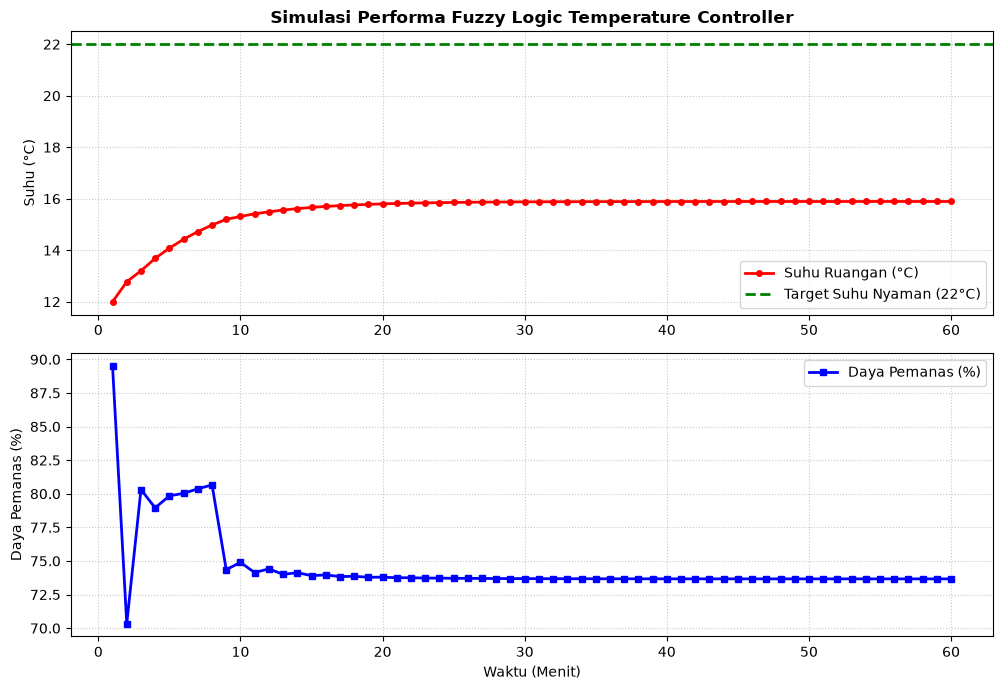

In [3]:
# ==============================================================================
# LANGKAH 1: DEFINISI VARIABEL DAN RENTANG NILAI (UNIVERSE OF DISCOURSE)
# ==============================================================================

# Suhu Ruangan: 0°C sampai 40°C dengan resolusi 1°C
room_temp = ctrl.Antecedent(np.arange(0, 41, 1), 'Room_Temperature')

# Laju Perubahan Suhu: -5°C/menit sampai +5°C/menit
rate_change = ctrl.Antecedent(np.arange(-5, 6, 1), 'Rate_of_Change')

# Daya Pemanas (Output): 0% sampai 100%
heater_power = ctrl.Consequent(np.arange(0, 101, 1), 'Heater_Power')

# ==============================================================================
# LANGKAH 2: FUNGSI KEANGGOTAAN (MEMBERSHIP FUNCTIONS)
# ==============================================================================

# Membership Functions untuk Suhu Ruangan (Room_Temperature)
room_temp['Cold'] = fuzz.trapmf(room_temp.universe, [0, 0, 10, 18])
room_temp['Cool'] = fuzz.trimf(room_temp.universe, [15, 20, 24])
room_temp['Warm'] = fuzz.trimf(room_temp.universe, [22, 26, 30])
room_temp['Hot']  = fuzz.trapmf(room_temp.universe, [28, 35, 40, 40])

# Membership Functions untuk Laju Perubahan Suhu (Rate_of_Change)
rate_change['Dropping'] = fuzz.trapmf(rate_change.universe, [-5, -5, -3, 0])
rate_change['Steady']   = fuzz.trimf(rate_change.universe, [-1, 0, 1])
rate_change['Rising']   = fuzz.trapmf(rate_change.universe, [0, 3, 5, 5])

# Membership Functions untuk Daya Pemanas (Heater_Power)
heater_power['Off']    = fuzz.trimf(heater_power.universe, [0, 0, 10])
heater_power['Low']    = fuzz.trimf(heater_power.universe, [5, 25, 50])
heater_power['Medium'] = fuzz.trimf(heater_power.universe, [40, 60, 80])
heater_power['High']   = fuzz.trimf(heater_power.universe, [70, 100, 100])

# ==============================================================================
# LANGKAH 3: ATURAN LOGIKA FUZZY (FUZZY RULES)
# ==============================================================================

rule1 = ctrl.Rule(room_temp['Cold'] & rate_change['Dropping'], heater_power['High'])
rule2 = ctrl.Rule(room_temp['Cold'] & rate_change['Steady'],   heater_power['High'])
rule3 = ctrl.Rule(room_temp['Cold'] & rate_change['Rising'],   heater_power['Medium'])

rule4 = ctrl.Rule(room_temp['Cool'] & rate_change['Dropping'], heater_power['High'])
rule5 = ctrl.Rule(room_temp['Cool'] & rate_change['Steady'],   heater_power['Medium'])
rule6 = ctrl.Rule(room_temp['Cool'] & rate_change['Rising'],   heater_power['Low'])

rule7 = ctrl.Rule(room_temp['Warm'] & rate_change['Dropping'], heater_power['Low'])
rule8 = ctrl.Rule(room_temp['Warm'] & rate_change['Steady'],   heater_power['Off'])
rule9 = ctrl.Rule(room_temp['Warm'] & rate_change['Rising'],   heater_power['Off'])

rule10 = ctrl.Rule(room_temp['Hot'], heater_power['Off'])

# Membangun sistem kontrol fuzzy
heater_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, 
    rule6, rule7, rule8, rule9, rule10
])
heater_sim = ctrl.ControlSystemSimulation(heater_ctrl)

# ==============================================================================
# LANGKAH 4: SIMULASI DINAMIKA SUHU RUANGAN (60 MENIT)
# ==============================================================================

waktu_simulasi = 60  # Durasi simulasi dalam menit
suhu_luar = 10.0    # Suhu udara di luar ruangan (°C)
suhu_sekarang = 12.0 # Suhu awal ruangan (°C)
suhu_sebelumnya = 12.0

# Array untuk menyimpan riwayat data untuk plotting
data_suhu = []
data_daya = []
data_laju = []

print("Mulai simulasi kontrol pemanas berbasis Fuzzy Logic...\n")

for t in range(waktu_simulasi):
    # Hitung laju perubahan suhu (°C / menit)
    laju_ubah = suhu_sekarang - suhu_sebelumnya
    
    # Batasi input agar tidak melebihi rentang universe
    input_suhu = np.clip(suhu_sekarang, 0, 40)
    input_laju = np.clip(laju_ubah, -5, 5)
    
    # Masukkan data variabel input ke pengontrol fuzzy
    heater_sim.input['Room_Temperature'] = input_suhu
    heater_sim.input['Rate_of_Change']   = input_laju
    
    # Jalankan inferensi fuzzy (Defuzzifikasi)
    heater_sim.compute()
    daya_pemanas = heater_sim.output['Heater_Power']
    
    # Simpan hasil untuk grafik
    data_suhu.append(suhu_sekarang)
    data_daya.append(daya_pemanas)
    data_laju.append(laju_ubah)
    
    # Tampilkan log ringkas di terminal
    print(f"Menit ke-{t+1:02d} | Suhu: {suhu_sekarang:.2f}°C | Laju: {laju_ubah:+.2f}°C/min | Daya Heater: {daya_pemanas:.2f}%")
    
    # Persamaan Fisika Sederhana Ruangan:
    # 1. Penurunan suhu akibat udara dingin di luar
    pendinginan = 0.15 * (suhu_sekarang - suhu_luar)
    # 2. Kenaikan suhu akibat panas yang dihasilkan pemanas
    pemanasan = 0.08 * (daya_pemanas / 100.0) * 15.0
    
    # Update nilai suhu untuk langkah berikutnya
    suhu_sebelumnya = suhu_sekarang
    suhu_sekarang = suhu_sekarang + pemanasan - pendinginan

print("\nSimulasi selesai! Menampilkan grafik...")

# ==============================================================================
# LANGKAH 5: VISUALISASI HASIL SIMULASI (PLOT GRAFIK)
# ==============================================================================

plt.figure(figsize=(10, 7))

# Plot Grafik 1: Suhu Ruangan vs Waktu
plt.subplot(2, 1, 1)
plt.plot(range(1, waktu_simulasi + 1), data_suhu, 'r-o', linewidth=2, markersize=4, label='Suhu Ruangan (°C)')
plt.axhline(y=22, color='g', linestyle='--', linewidth=2, label='Target Suhu Nyaman (22°C)')
plt.title('Simulasi Performa Fuzzy Logic Temperature Controller', fontsize=12, fontweight='bold')
plt.ylabel('Suhu (°C)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')

# Plot Grafik 2: Daya Pemanas (%) vs Waktu
plt.subplot(2, 1, 2)
plt.plot(range(1, waktu_simulasi + 1), data_daya, 'b-s', linewidth=2, markersize=4, label='Daya Pemanas (%)')
plt.xlabel('Waktu (Menit)')
plt.ylabel('Daya Pemanas (%)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()